In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import cftime
import calendar
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.path as mpath
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.ticker as mticker
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle
import imageio
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime #import datetime
from glob import glob

In [2]:
# dask
import dask
import dask.array as da
import distributed
from dask.distributed import Client

client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 8
Total threads: 32,Total memory: 35.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35259,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:40197,Total threads: 4
Dashboard: http://127.0.0.1:42835/status,Memory: 4.38 GiB
Nanny: tcp://127.0.0.1:45895,


In [3]:
path_atm = "/projects/NS1004K/elihho/NHIST_tropochem_250916/atm/hist"
ds = xr.open_mfdataset(f"{path_atm}/NHIST_tropstratchem_f09_tn14_20250917_1975_2014.cam.h0.*.nc", combine="by_coords", parallel=True)

In [3]:
path_obs = "/nird/projects/NS1004K/elihho/obs_pinatubo/dataset/Observation"


/tmp/ipykernel_29830/2270931133.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  hirs_sulf_burd = pd.read_csv(f"{path_obs}/hirs_sulf_burd.txt", delim_whitespace=True, header=0,  index_col=0)
/tmp/ipykernel_29830/2270931133.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  sage3l_sulf_burd = pd.read_csv(f"{path_obs}/sage3l_sulf_burd.txt", delim_whitespace=True, header=0,  index_col=0)


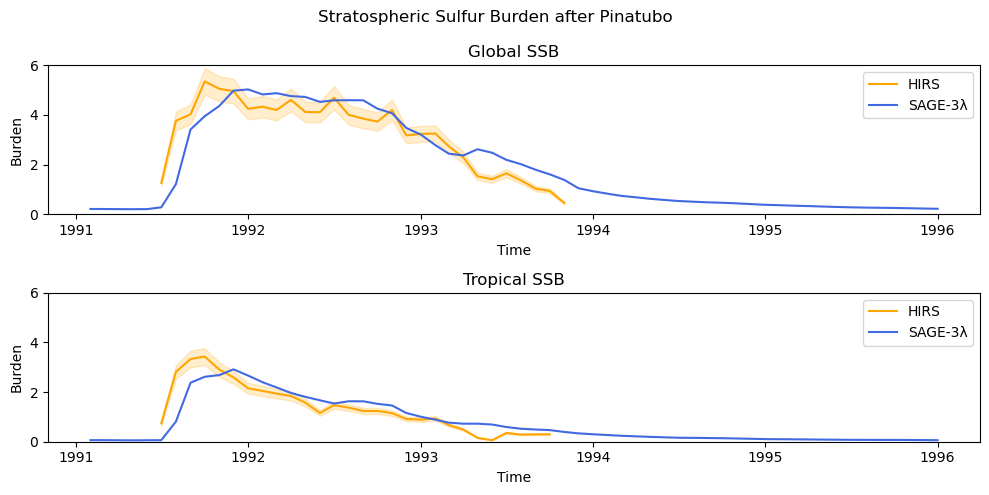

In [38]:
hirs_sulf_burd = pd.read_csv(f"{path_obs}/hirs_sulf_burd.txt", delim_whitespace=True, header=0,  index_col=0)
sage3l_sulf_burd = pd.read_csv(f"{path_obs}/sage3l_sulf_burd.txt", delim_whitespace=True, header=0,  index_col=0)

start = pd.Timestamp("1991-01-01")
months = [int(c) for c in hirs_sulf_burd.columns]
dates = [start + pd.DateOffset(months=m) for m in months]
hirs_sulf_burd.columns = dates

months_sage = [int(c) for c in sage3l_sulf_burd.columns]
dates_sage = [start + pd.DateOffset(months=m) for m in months_sage]
sage3l_sulf_burd.columns = dates_sage

total = hirs_sulf_burd.loc["Total_burden"].astype(float)
trop  = hirs_sulf_burd.loc["Tropical_burden"].astype(float)
err_total = hirs_sulf_burd.loc["Total_burden_error"].astype(float)
err_trop =  hirs_sulf_burd.loc["Tropical_burden_error"].astype(float)

total_sage = sage3l_sulf_burd.loc["Global"].astype(float)
trop_sage  = sage3l_sulf_burd.loc["Tropical"].astype(float)

fig, ax = plt.subplots(2, 1, figsize=(10, 5))
ax[0].plot(total.index, total, color="orange", label="HIRS")
ax[0].fill_between(total.index, total - err_total, total + err_total,
                 color="orange", alpha=0.2)
ax[0].plot(total_sage.index, total_sage, color="royalblue", label="SAGE-3λ")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Burden")
ax[0].set_ylim(0,6)
ax[0].set_title("Global SSB")
ax[0].legend()

ax[1].plot(trop.index,  trop,  color="orange", label="HIRS")
ax[1].fill_between(total.index, trop - err_trop, trop + err_trop,
                 color="orange", alpha=0.2)
ax[1].plot(trop_sage.index, trop_sage, color="royalblue", label="SAGE-3λ")
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Burden")
ax[1].set_ylim(0,6)
ax[1].set_title("Tropical SSB")
ax[1].legend()


fig.suptitle("Stratospheric Sulfur Burden after Pinatubo")
plt.tight_layout()
plt.show()
